# First Data Exploration

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

## Importing the dataset

In [2]:
IMG_SIZE = (200, 300) # Suggested sizes by the dataset source
BATCH_SIZE = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/raw/Motorbikes",
    labels=None,
    image_size=IMG_SIZE,
    shuffle=False,
    batch_size=BATCH_SIZE
)

Found 211 files.


## Plotting some of the images to see how they look like

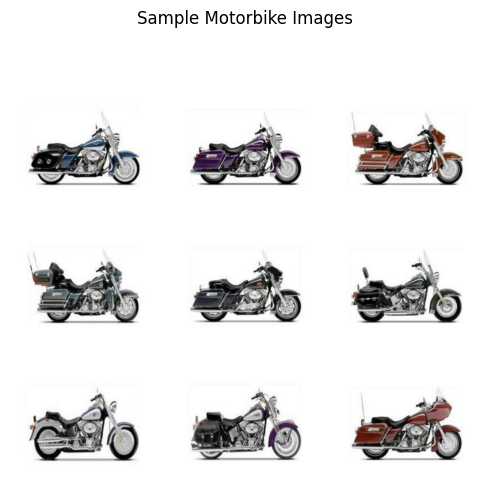

In [3]:
first_batch = next(iter(dataset))  
images = first_batch[:9].numpy().astype("uint8")

plt.figure(figsize=(5, 5))
for i in range(len(images)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")
plt.suptitle("Sample Motorbike Images", y=1.02)
plt.tight_layout()
plt.show()

## Extracting all images

In [4]:
# Convert the dataset to a NumPy array for easier manipulation
all_images = []
for batch in dataset:
    all_images.extend(batch.numpy())

all_images = np.array(all_images)
image_shape = all_images.shape[1:]
print(f"Image shape: {image_shape}")

Image shape: (200, 300, 3)


2026-02-24 11:52:31.907638: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Split the dataset into training and testing sets

In [5]:
x_train, x_test = train_test_split(all_images, test_size=0.2, random_state=42)
print(f"Training set size: {len(x_train)}")
print(f"Testing set size: {len(x_test)}")

Training set size: 168
Testing set size: 43


## Save processed data

In [6]:
np.save("../data/processed/x_train.npy", x_train.astype("uint8"))
np.save("../data/processed/x_test.npy", x_test.astype("uint8"))